In [68]:
import torch
import matplotlib.pyplot as plt


def plot_tensor_heatmap(
    tensor: torch.Tensor,
    title: str = "Heatmap do Tensor",
    xlabel: str = "Índice da coluna",
    ylabel: str = "Índice da linha",
    annotate: bool = False,
    fmt: str = ".2f",
    save_path: str | None = None,
) -> None:
    """
    Plota o heatmap de um tensor PyTorch bidimensional.

    Parameters
    ----------
    tensor : torch.Tensor
        Tensor 2D que será representado no heatmap.
    title : str
        Título do gráfico.
    xlabel : str
        Rótulo do eixo x.
    ylabel : str
        Rótulo do eixo y.
    annotate : bool
        Se True, escreve o valor de cada célula.
        Recomenda-se usar apenas para matrizes pequenas.
    fmt : str
        Formato numérico utilizado nas anotações.
    save_path : str | None
        Caminho para salvar a figura. Exemplo: "heatmap.png".
        Se None, a figura não será salva.
    """

    if not isinstance(tensor, torch.Tensor):
        raise TypeError("A entrada deve ser um torch.Tensor.")

    if tensor.ndim != 2:
        raise ValueError(
            f"O tensor deve ser bidimensional, mas possui shape {tuple(tensor.shape)}."
        )

    # Remove o tensor do grafo computacional, transfere para a CPU
    # e converte para array NumPy.
    matrix = tensor.detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(4,3), dpi=300)

    heatmap = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="viridis",
    )

    ax.set_title(title, fontsize=14, pad=12)
    # ax.set_xlabel(xlabel, fontsize=8)
    # ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis="both", labelsize=10)

    # Barra lateral indicando a escala dos valores.
    cbar = fig.colorbar(heatmap, ax=ax)
    cbar.set_label("Valor", fontsize=8)
    cbar.ax.tick_params(labelsize=10)

    # Escreve os valores nas células para matrizes pequenas.
    if annotate:
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(
                    j,
                    i,
                    format(matrix[i, j], fmt),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                )

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [80]:
import torch
from models.SCatt import SCAttGenerator

y_vals = [200,180,160,140,120,100,80]
e_vals = [500,460,420,380,340,300,160]

for index in range(7):
    k = 9
    dst = ["power_law", "power_law", "power_law", "normal", "normal", "normal", "uniform", "uniform","uniform"]

    # y = [200,200,200,200,200,200,200,200,200]
    # e = [500,500,500,500,500,500,500,500,500]

    y = [200, y_vals[index], y_vals[index]] * 3
    e = [500, e_vals[index], e_vals[index]] * 3
    rho = 5500

    S = [torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1]),torch.tensor([1])]

    A_in = S

    prob_values = [1/8, 1/7, 1/6, 1/5, 1/4, 1/3, 1/2]
    A_out = torch.tensor([
        [
            prob_values[index] if dst[i] == dst[j] else (1 - 2 * prob_values[index]) / 6
            for i in range(len(dst))
        ]
        for j in range(len(dst))
    ]).fill_diagonal_(0)

    graph = SCAttGenerator(seed = 1010).generate(n = sum(y), y=y, k=k, e=e, A_in=A_in, A_out=A_out, S=S, alpha_feat=0.5, alpha_topo=0.5,dst=dst, rho = rho, d = 60)

    dt = graph.to_data_pytorch()

    torch.save(dt, f"graph_comm_colapse_{index}.pt")

In [76]:
graph = SCAttGenerator(seed = 1010).generate(n = sum(y), y=y, k=k, e=e, A_in=A_in, A_out=A_out, S=S, alpha_feat=0.5, alpha_topo=0.5,dst=dst, rho = rho, d = 60)

In [77]:
graph

AttributedGraph(n_nodes=1800, n_edges=5500, x_shape=(1800, 60), y_shape=(1800,))

In [114]:
from pathlib import Path

import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_networkit

from core.attributed_graph import AttributedGraph
from models.GenCAT import GenCATGenerator
from models.SkyMap import SkyMapGenerator
from models.chunglu import ChungLuGenerator


# ============================================================
# Carrega Cora
# ============================================================

cora_path = Path("datasets/Cora/processed/data.pt")

raw = torch.load(cora_path, map_location="cpu")

# O dataset processado do PyG geralmente vem como (data, slices).
if isinstance(raw, tuple):
    raw_data = raw[0]
else:
    raw_data = raw

# Em alguns pontos do repo raw_data aparece como dict-like.
if isinstance(raw_data, Data):
    cora_data = raw_data
else:
    cora_data = Data(
        x=raw_data["x"],
        y=raw_data["y"],
        edge_index=raw_data["edge_index"],
    )

cora_graph = AttributedGraph(
    graph=to_networkit(cora_data.edge_index, directed=False),
    x=cora_data.x,
    y=cora_data.y,
)

print("Cora original:", cora_graph)


# ============================================================
# Clona com os modelos
# ============================================================

seed = 42

models = {
    # "cora_gencat": GenCATGenerator(),
    # "cora_skymap": SkyMapGenerator(),
    # "cora_chunglu": ChungLuGenerator(seed=seed),
    "cora_scatt": SCAttGenerator()
}

cloned_graphs = {}

for name, model in models.items():
    print(f"Clonando com {name}...")

    if name == "cora_gencat":
        # feature_dim controla a dimensionalidade de X gerada pelo GenCAT.
        # Para manter igual ao Cora:
        graph_clone = model.mimic(
            cora_graph,
            feature_dim=cora_graph.x.shape[1],
        )

    elif name == "cora_chunglu":
        # copy_x=True preserva features por classe; sem isso, Chung-Lu retorna X zerado.
        graph_clone = model.mimic(
            cora_graph,
            seed=seed,
            copy_x=True,
            shuffle_x_within_class=True,
        )

    else:
        graph_clone = model.mimic(cora_graph)

    cloned_graphs[name] = graph_clone
    print(f"{name}:", graph_clone)


# ============================================================
# Salva os grafos clonados
# ============================================================

out_dir = Path(".")
# Se preferir uma pasta:
# out_dir = Path("cloned_graphs")
# out_dir.mkdir(parents=True, exist_ok=True)

for name, graph_clone in cloned_graphs.items():
    save_path = out_dir / f"{name}.pt"
    torch.save(graph_clone.to_data_pytorch(), save_path)
    print(f"Salvo em: {save_path}")

Cora original: AttributedGraph(n_nodes=2708, n_edges=5278, x_shape=(2708, 1433), y_shape=(2708,))
Clonando com cora_scatt...
cora_scatt: AttributedGraph(n_nodes=2708, n_edges=5497, x_shape=(2708, 1433), y_shape=(2708,))
Salvo em: cora_scatt.pt


In [109]:
import networkit as nk

from core.attributed_graph import AttributedGraph


def keep_largest_connected_component(graph: AttributedGraph) -> AttributedGraph:
    cc = nk.components.ConnectedComponents(graph.graph)
    cc.run()

    components = cc.getComponents()
    if not components:
        return graph

    largest_component = max(components, key=len)
    nodes_to_keep = sorted(int(node) for node in largest_component)

    old_to_new = {
        old: new
        for new, old in enumerate(nodes_to_keep)
    }

    new_graph = nk.Graph(
        len(nodes_to_keep),
        weighted=False,
        directed=False,
    )

    for u, v in graph.graph.iterEdges():
        u = int(u)
        v = int(v)

        if u in old_to_new and v in old_to_new:
            new_u = old_to_new[u]
            new_v = old_to_new[v]

            if new_u != new_v and not new_graph.hasEdge(new_u, new_v):
                new_graph.addEdge(new_u, new_v)

    x = graph.x[nodes_to_keep]

    y = None
    if graph.y is not None:
        y = graph.y[nodes_to_keep]

    return AttributedGraph(
        graph=new_graph,
        x=x,
        y=y,
    )

Cora 2708 nodes / 5278 edges -> 102 nodes / 172 edges


/home/gui-messias/miniconda3/envs/graphgen_venv/lib/python3.10/site-packages/netgraph/_node_layout.py:1550: UserWarning: Graph contains a single community. Unable to compute a community layout. Computing spring layout instead.
  warnings.warn("Graph contains a single community. Unable to compute a community layout. Computing spring layout instead.")
/home/gui-messias/miniconda3/envs/graphgen_venv/lib/python3.10/site-packages/netgraph/_utils.py:360: RuntimeWarning: invalid value encountered in divide
  v = v / np.linalg.norm(v, axis=-1)[:, None] # unit vector


GenCAT 2708 nodes / 5541 edges -> 131 nodes / 221 edges
SkyMap 2712 nodes / 5270 edges -> 168 nodes / 262 edges
Chung-Lu 2708 nodes / 5278 edges -> 146 nodes / 252 edges
SCAtt 2708 nodes / 5497 edges -> 102 nodes / 151 edges


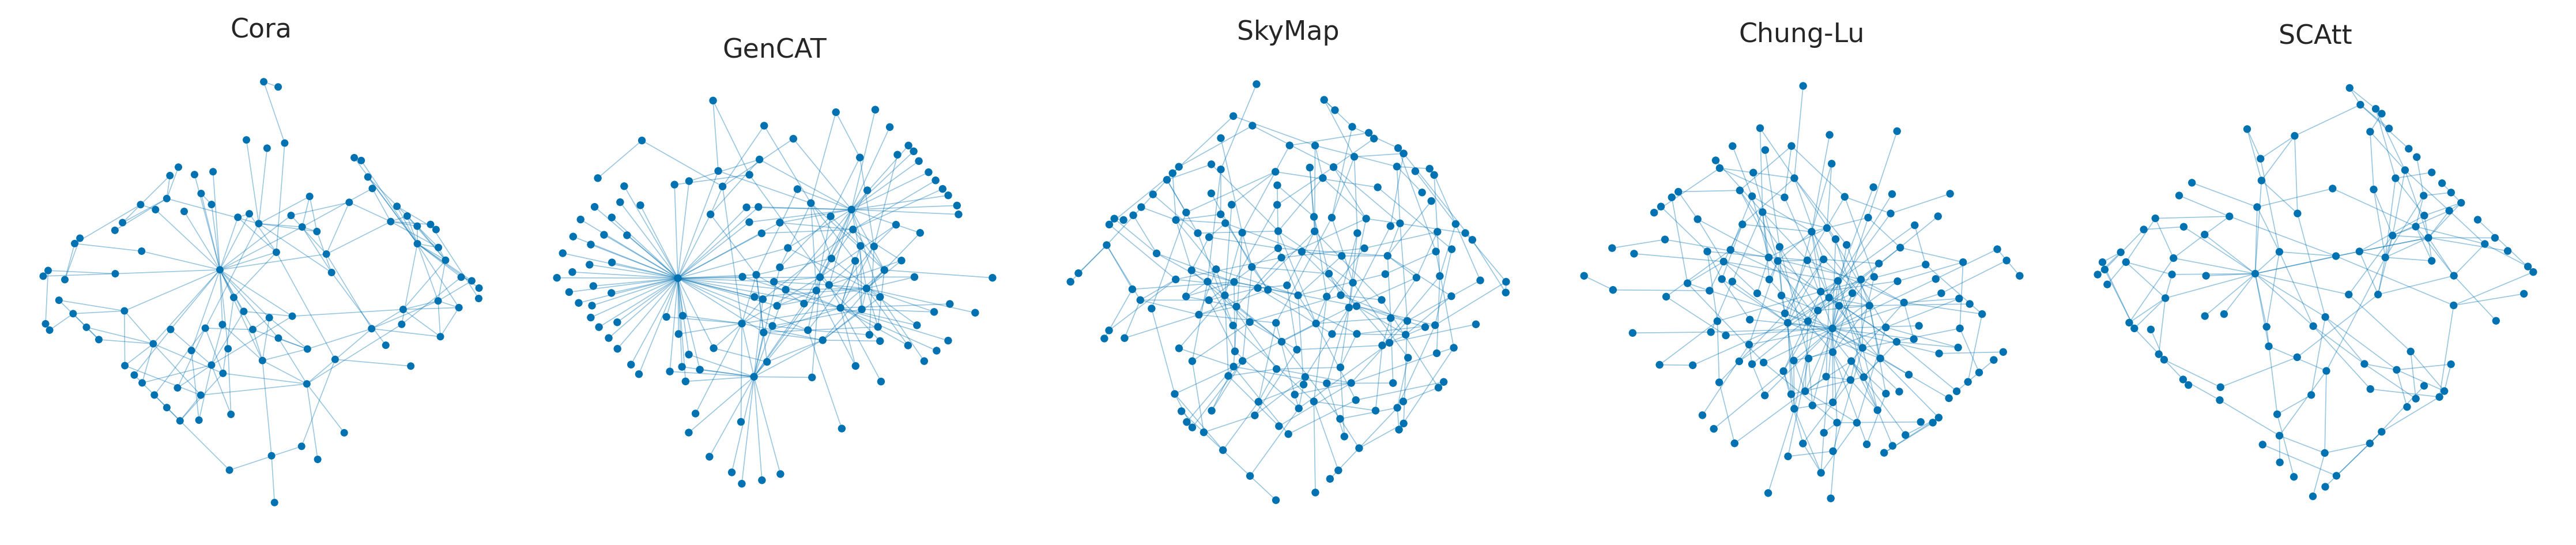

In [2]:
from pathlib import Path

import torch
import networkit as nk
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.utils import to_networkit

from core.attributed_graph import AttributedGraph
from plot.plot import PublicationPlotStyle, graphPlotter


def load_pt_as_attributed_graph(path):
    obj = torch.load(path, map_location="cpu")

    if isinstance(obj, AttributedGraph):
        return obj

    if isinstance(obj, tuple):
        obj = obj[0]

    if isinstance(obj, Data):
        data = obj
    else:
        data = Data(
            x=obj["x"],
            y=obj["y"],
            edge_index=obj["edge_index"],
        )

    return AttributedGraph(
        graph=to_networkit(data.edge_index, directed=False),
        x=data.x,
        y=data.y,
    )


def keep_class_largest_connected_component(graph: AttributedGraph, class_id: int) -> AttributedGraph:
    nodes_of_class = [
        int(node)
        for node in graph.graph.iterNodes()
        if int(graph.y[int(node)]) == int(class_id)
    ]

    if len(nodes_of_class) == 0:
        raise ValueError(f"Nenhum vertice encontrado para class_id={class_id}")

    node_set = set(nodes_of_class)

    old_to_tmp = {
        old: tmp
        for tmp, old in enumerate(nodes_of_class)
    }

    tmp_to_old = {
        tmp: old
        for old, tmp in old_to_tmp.items()
    }

    class_graph = nk.Graph(
        len(nodes_of_class),
        weighted=False,
        directed=False,
    )

    for u, v in graph.graph.iterEdges():
        u = int(u)
        v = int(v)

        if u in node_set and v in node_set:
            tu = old_to_tmp[u]
            tv = old_to_tmp[v]

            if tu != tv and not class_graph.hasEdge(tu, tv):
                class_graph.addEdge(tu, tv)

    cc = nk.components.ConnectedComponents(class_graph)
    cc.run()

    components = cc.getComponents()
    largest_tmp_component = max(components, key=len)

    nodes_to_keep = sorted(
        tmp_to_old[int(tmp)]
        for tmp in largest_tmp_component
    )

    old_to_new = {
        old: new
        for new, old in enumerate(nodes_to_keep)
    }

    new_graph = nk.Graph(
        len(nodes_to_keep),
        weighted=False,
        directed=False,
    )

    for u, v in graph.graph.iterEdges():
        u = int(u)
        v = int(v)

        if u in old_to_new and v in old_to_new:
            nu = old_to_new[u]
            nv = old_to_new[v]

            if nu != nv and not new_graph.hasEdge(nu, nv):
                new_graph.addEdge(nu, nv)

    return AttributedGraph(
        graph=new_graph,
        x=graph.x[nodes_to_keep],
        y=graph.y[nodes_to_keep],
    )


paths = [
    Path("datasets/Cora/processed/data.pt"),
    Path("cora_gencat.pt"),
    Path("cora_skymap.pt"),
    Path("cora_chunglu.pt"),
    Path("cora_scatt.pt")
]

titles = [
    "Cora",
    "GenCAT",
    "SkyMap",
    "Chung-Lu",
    "SCAtt"
]

class_id = 6

style = PublicationPlotStyle(
    figsize=(5.2, 4.8),
    dpi=300,
    node_size=0.8,
    edge_width=0.2,
    edge_alpha=0.4,
    class_edge_alpha=0.4,
    interclass_edge_alpha=0.4,
    color_intraclass_edges=True,
    community_distance=1.25,
    show_legend=False,
)

plotter = graphPlotter(style)

fig, axes = plt.subplots(1, 5, figsize=(15, 4.8), dpi=300)

for ax, path, title in zip(axes, paths, titles):
    graph = load_pt_as_attributed_graph(path)

    before_nodes = graph.num_nodes()
    before_edges = graph.num_edges()

    graph = keep_class_largest_connected_component(graph, class_id)

    print(
        title,
        f"{before_nodes} nodes / {before_edges} edges -> "
        f"{graph.num_nodes()} nodes / {graph.num_edges()} edges"
    )

    plotter.plot_scatt_graph(
        graph,
        layout="community",
        edge_layout="straight",
        title=title,
        ax=ax,
        class_id=class_id,
    )

fig.tight_layout()
plt.savefig("why_scatt.svg")
plt.show()



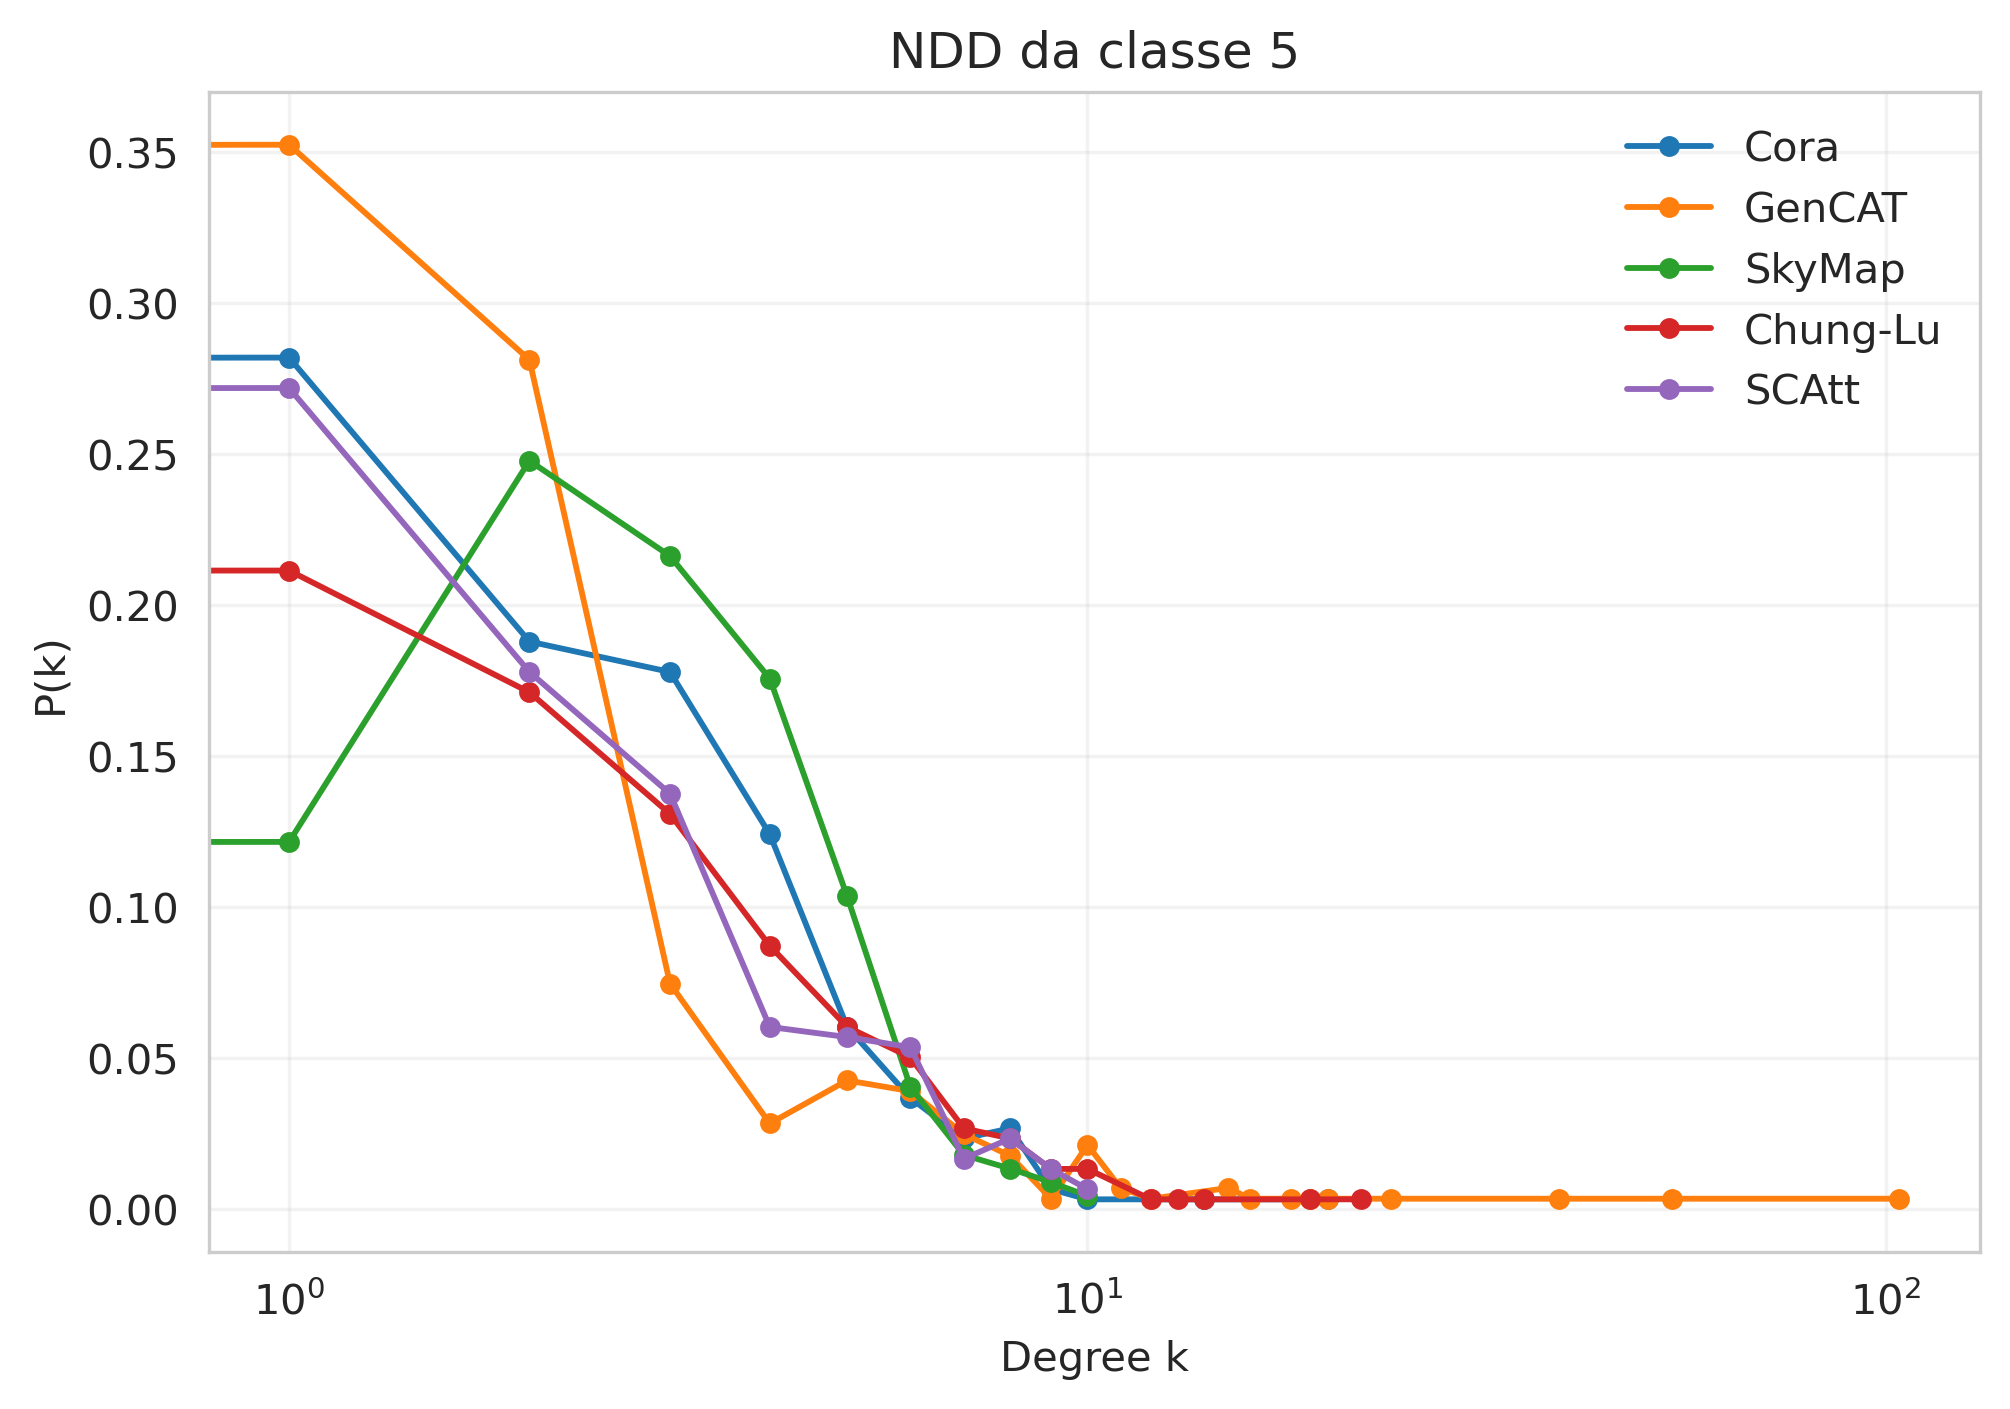

In [123]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import networkit as nk

from torch_geometric.data import Data
from torch_geometric.utils import to_networkit

from core.attributed_graph import AttributedGraph


def load_pt_as_attributed_graph(path):
    obj = torch.load(path, map_location="cpu")

    if isinstance(obj, AttributedGraph):
        return obj

    if isinstance(obj, tuple):
        obj = obj[0]

    if isinstance(obj, Data):
        data = obj
    else:
        data = Data(
            x=obj["x"],
            y=obj["y"],
            edge_index=obj["edge_index"],
        )

    return AttributedGraph(
        graph=to_networkit(data.edge_index, directed=False),
        x=data.x,
        y=data.y,
    )


def class_induced_subgraph(graph: AttributedGraph, class_id: int) -> AttributedGraph:
    nodes = [
        int(node)
        for node in graph.graph.iterNodes()
        if int(graph.y[int(node)]) == int(class_id)
    ]

    old_to_new = {old: new for new, old in enumerate(nodes)}

    new_graph = nk.Graph(
        len(nodes),
        weighted=False,
        directed=False,
    )

    for u, v in graph.graph.iterEdges():
        u = int(u)
        v = int(v)

        if u in old_to_new and v in old_to_new:
            nu = old_to_new[u]
            nv = old_to_new[v]

            if nu != nv and not new_graph.hasEdge(nu, nv):
                new_graph.addEdge(nu, nv)

    return AttributedGraph(
        graph=new_graph,
        x=graph.x[nodes],
        y=graph.y[nodes],
    )


def degree_distribution(graph: AttributedGraph, density=True):
    degrees = np.array(
        [graph.graph.degree(node) for node in graph.graph.iterNodes()],
        dtype=int,
    )

    if len(degrees) == 0:
        return np.array([]), np.array([])

    counts = np.bincount(degrees)
    k_values = np.arange(len(counts))

    mask = counts > 0
    k_values = k_values[mask]
    counts = counts[mask].astype(float)

    if density:
        counts = counts / counts.sum()

    return k_values, counts


paths = [
    Path("datasets/Cora/processed/data.pt"),
    Path("cora_gencat.pt"),
    Path("cora_skymap.pt"),
    Path("cora_chunglu.pt"),
    Path("cora_scatt.pt")
]

titles = [
    "Cora",
    "GenCAT",
    "SkyMap",
    "Chung-Lu",
    "SCAtt"
]

class_id = 5

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=300)

for path, title in zip(paths, titles):
    graph = load_pt_as_attributed_graph(path)
    graph_class = class_induced_subgraph(graph, class_id)

    k_values, probs = degree_distribution(graph_class, density=True)

    ax.plot(
        k_values,
        probs,
        marker="o",
        linewidth=1.4,
        markersize=4,
        label=title,
    )

ax.set_title(f"NDD da classe {class_id}")
ax.set_xlabel("Degree k")
ax.set_ylabel("P(k)")
ax.grid(alpha=0.25)
ax.set_xscale("log")
# ax.set_yscale("log")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [118]:
import numpy as np
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance


def degree_array(graph):
    return np.array(
        [graph.graph.degree(node) for node in graph.graph.iterNodes()],
        dtype=int,
    )


def degree_pmf(degrees, max_degree=None):
    if max_degree is None:
        max_degree = int(degrees.max()) if len(degrees) else 0

    counts = np.bincount(degrees, minlength=max_degree + 1).astype(float)

    if counts.sum() > 0:
        counts = counts / counts.sum()

    return counts


def compare_ndd(graph_original, graph_clone, tail_min_degree=None):
    deg_original = degree_array(graph_original)
    deg_clone = degree_array(graph_clone)

    max_degree = int(max(
        deg_original.max() if len(deg_original) else 0,
        deg_clone.max() if len(deg_clone) else 0,
    ))

    p = degree_pmf(deg_original, max_degree=max_degree)
    q = degree_pmf(deg_clone, max_degree=max_degree)

    cdf_p = np.cumsum(p)
    cdf_q = np.cumsum(q)

    ks = np.max(np.abs(cdf_p - cdf_q))
    tvd = 0.5 * np.sum(np.abs(p - q))
    js = jensenshannon(p, q, base=2.0)
    wasserstein = wasserstein_distance(deg_original, deg_clone)

    out = {
        "ks": float(ks),
        "tvd": float(tvd),
        "js_distance": float(js),
        "wasserstein": float(wasserstein),
        "mean_degree_original": float(deg_original.mean()),
        "mean_degree_clone": float(deg_clone.mean()),
        "max_degree_original": int(deg_original.max()),
        "max_degree_clone": int(deg_clone.max()),
    }

    if tail_min_degree is not None:
        tail_mask = np.arange(max_degree + 1) >= tail_min_degree

        p_tail = p[tail_mask]
        q_tail = q[tail_mask]

        if p_tail.sum() > 0:
            p_tail = p_tail / p_tail.sum()
        if q_tail.sum() > 0:
            q_tail = q_tail / q_tail.sum()

        tail_cdf_p = np.cumsum(p_tail)
        tail_cdf_q = np.cumsum(q_tail)

        out["tail_ks"] = float(np.max(np.abs(tail_cdf_p - tail_cdf_q)))
        out["tail_tvd"] = float(0.5 * np.sum(np.abs(p_tail - q_tail)))

    return out

In [120]:
original = load_pt_as_attributed_graph("datasets/Cora/processed/data.pt")
gencat = load_pt_as_attributed_graph("cora_gencat.pt")
skymap = load_pt_as_attributed_graph("cora_skymap.pt")
chunglu = load_pt_as_attributed_graph("cora_chunglu.pt")
scatt = load_pt_as_attributed_graph("scatt_graph.pt")

compare_ndd(original, gencat, tail_min_degree=5)

{'ks': 0.293943870014771,
 'tvd': 0.31868537666174296,
 'js_distance': 0.30667333124805035,
 'wasserstein': 1.8862629246676537,
 'mean_degree_original': 3.8980797636632203,
 'mean_degree_clone': 4.09231905465288,
 'max_degree_original': 168,
 'max_degree_clone': 264,
 'tail_ks': 0.23175122197876274,
 'tail_tvd': 0.24331704028316187}

In [121]:
compare_ndd(original, scatt, tail_min_degree=5)

{'ks': 0.12470034142915953,
 'tvd': 0.13963786715742063,
 'js_distance': 0.1876559374202546,
 'wasserstein': 1.0228164273433873,
 'mean_degree_original': 3.8980797636632203,
 'mean_degree_clone': 4.872950819672131,
 'max_degree_original': 168,
 'max_degree_clone': 121,
 'tail_ks': 0.1337615922605292,
 'tail_tvd': 0.20465539020858364}